In [ ]:
# If you do not have this library installed, use pip install pyserial
import serial

# Settings
PORT = 'COM6' # Check device manager for the correct COM port
BAUD = 115200 # Baud rate of the TRNG device
FILE_NAME = r"C:\Users\Dylan\Downloads\TRNG_python\trng_results.bin" # Output binary file of data, change to directory you want to save to
BYTES_TO_COLLECT = 1_000_000  # 1 MB of random data

try:
    ser = serial.Serial(PORT, BAUD, timeout=2) # Open serial port
    print(f"Connected to {PORT}. Collecting {BYTES_TO_COLLECT} bytes...")

    with open(FILE_NAME, "wb") as f:
        bytes_captured = 0
        while bytes_captured < BYTES_TO_COLLECT:
            # Read available data from the serial port and write data to binary file
            if ser.in_waiting > 0:
                chunk = ser.read(ser.in_waiting)
                f.write(chunk)
                bytes_captured += len(chunk)
                # Print progress every 10%
                if bytes_captured % (BYTES_TO_COLLECT // 10) < 100:
                    print(f"Progress: {bytes_captured/BYTES_TO_COLLECT:.1%}")

    print(f"Done! Data saved to {FILE_NAME}")

except Exception as e:
    print(f"Error: {e}")
finally:
    ser.close()

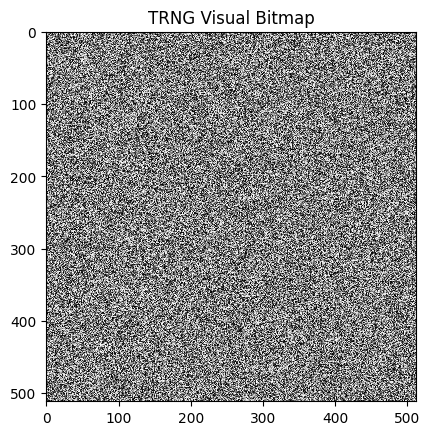

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load your binary file from previous step
data = np.fromfile(r"C:\Users\Dylan\Downloads\TRNG_python\trng_results.bin", dtype=np.uint8)

# Create a Bitmap (visualize bits)
# Reshape into a square (e.g., 512x512)
side = 512
bitmap = data[:side*side].reshape((side, side))

plt.imshow(bitmap, cmap='gray', interpolation='nearest')
plt.title("TRNG Visual Bitmap")
plt.show()

Analyzing 1000006 bytes...
Shannon Entropy: 7.999465 bits/byte (Ideal: 8.0)


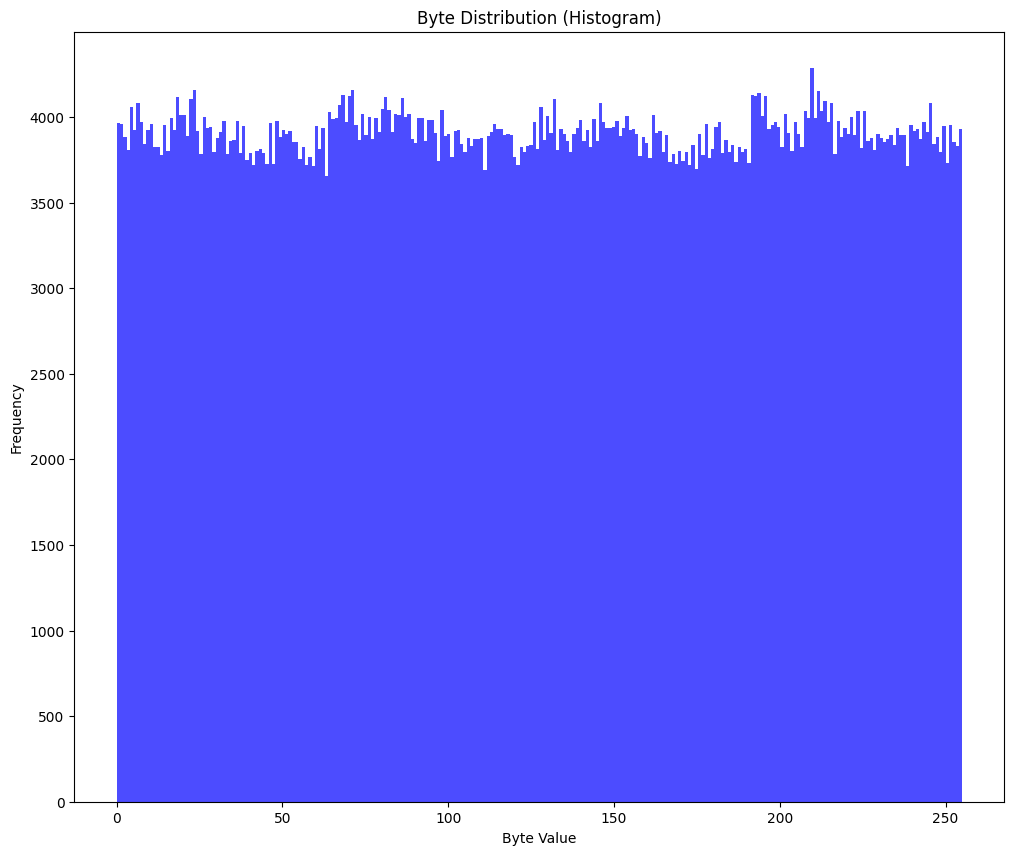

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load your binary file from previous step
data = np.fromfile(r"C:\Users\Dylan\Downloads\TRNG_python\trng_results.bin", dtype=np.uint8)

# Calculate Shannon Entropy (this shows randomness quality, ideal is 8 bits/byte for truly random data)
def calculate_entropy(data):
    value, counts = np.unique(data, return_counts=True)
    probs = counts / len(data) # probabilities of each unique byte value
    n_classes = np.count_nonzero(probs) # Only want non-zero probabilities
    if n_classes <= 1:
        return 0
    ent = -np.sum(probs * np.log2(probs)) # entropy formula
    return ent

print(f"Shannon Entropy: {calculate_entropy(data):.6f} bits/byte (Ideal: 8.0)")

# Histogram (this shows the distribution of byte values, ideally should be uniform for random data)
plt.figure(figsize=(12, 10))

# Histogram has 256 bins for byte values 0-255
plt.hist(data, bins=256, range=(0, 255), color='blue', alpha=0.7)
plt.title("Byte Distribution (Histogram)")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")

plt.show()